# Superstore Sales — Exploratory Data Analysis
EDA performed ahead of star-schema design (fact/dimension modeling).

## 0. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("../data/raw/train.csv")

## 1. Basic structure check

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.shape

(9800, 18)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [6]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

In [7]:
df.info()  # NOTE: fixed — must call info() with parentheses, not just reference the method

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

**Insight:** The dataset has 9,800 rows and 18 columns. `Order Date` and `Ship Date` are loaded as `object` (string) dtype, not datetime — these need explicit conversion before any date-based analysis or before building `dim_date`. `Postal Code` is `float64` because of the missing values found below (NaNs force the column out of integer dtype); once nulls are handled it should be cast to a string/int, since postal codes are identifiers, not quantities.

## 2. Missing values

In [8]:
df.isnull().sum()
# There are 11 missing values in Postal Code; every other column is complete.

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

**Insight:** Only `Postal Code` has missing values (11 rows, ~0.1% of the data) — low enough that dropping or imputing (e.g., looking up the correct postal code from City+State) is safe without meaningfully affecting the dataset. Since `dim_location` will be built from City/State/Region/Postal Code, these 11 rows should be resolved (imputed) rather than dropped, so `fact_sales` doesn't lose any order lines.

In [9]:
# Which rows have missing Postal Code — inspect them to decide on an imputation strategy
df[df['Postal Code'].isnull()][['City', 'State', 'Region', 'Postal Code']]

,City,State,Region,Postal Code
2234,Burlington,Vermont,East,NaN
5274,Burlington,Vermont,East,NaN
8798,Burlington,Vermont,East,NaN
9146,Burlington,Vermont,East,NaN
9147,Burlington,Vermont,East,NaN
9148,Burlington,Vermont,East,NaN
9386,Burlington,Vermont,East,NaN
9387,Burlington,Vermont,East,NaN
9388,Burlington,Vermont,East,NaN
9389,Burlington,Vermont,East,NaN


All 11 missing Postal Codes are the same single location: Burlington, Vermont, Region = East. That's not 11 separate unknowns, it's one missing lookup value repeated 11 times.

Burlington, VT has a real, findable ZIP code (05401). Since City+State+Region are already consistent across all 11 rows, we can safely impute all of them with the correct value rather than dropping any rows. We will do it in 02_schema_design notebook.

## 3. Duplicate checks

In [11]:
df.duplicated().sum()

0

Zero fully duplicated rows.

In [12]:
# Row ID should be unique per row (it's the source primary key)
df['Row ID'].is_unique

True

In [13]:
# Same Order ID appearing on multiple rows is EXPECTED — it means one order has multiple line items.
# This confirms the natural grain of the source data is order-line level, which should be the grain
# of fact_sales.
order_line_counts = df.groupby('Order ID').size()
print(f"Number of distinct orders: {order_line_counts.shape[0]}")
print(f"Avg line items per order: {order_line_counts.mean():.2f}")
print(f"Max line items in a single order: {order_line_counts.max()}")

Number of distinct orders: 4922
Avg line items per order: 1.99
Max line items in a single order: 14


**Insight:** `Row ID` is unique (confirms it's a safe surrogate/source key), while `Order ID` repeating across rows is expected and confirms the fact table's grain should be **one row per order line item**, not per order.

## 4. Cardinality of dimension candidates

In [14]:
print(f"distinct Customer id's {df['Customer ID'].nunique()}")
print(f"distinct Product ID {df['Product ID'].nunique()}")
print(f"distinct Region {df['Region'].nunique()}")
print(f"distinct Sub-Category {df['Sub-Category'].nunique()}")
print(f"distinct Segment {df['Segment'].nunique()}")
print(f"distinct Ship Mode {df['Ship Mode'].nunique()}")

distinct Customer id's 793
distinct Product ID 1861
distinct Region 4
distinct Sub-Category 17
distinct Segment 3
distinct Ship Mode 4


**Insight:** 793 unique customers and 1,861 unique products against 9,800 order lines means both `dim_customer` and `dim_product` will be far smaller than the fact table — exactly the shape you want in a star schema (small, reusable dimensions feeding a larger fact table). `Region` (4), `Segment` (3), and `Ship Mode` (4) are low-cardinality — good candidates either as their own small dimensions or as attributes folded into `dim_customer`/`dim_location`.

In [15]:
# Does each Customer ID always map to the same Customer Name, Segment, City, State?
# If nunique() > 1 for any of these per Customer ID, that ID is NOT safe to treat as a simple
# 1:1 dimension key without further investigation (it may indicate re-used IDs or real changes
# over time — relevant for how you design the SCD2 simulation later).
customer_consistency = df.groupby('Customer ID').agg(
    n_names=('Customer Name', 'nunique'),
    n_segments=('Segment', 'nunique'),
    n_cities=('City', 'nunique'),
    n_states=('State', 'nunique'),
)

inconsistent_customers = customer_consistency[
    (customer_consistency['n_names'] > 1) |
    (customer_consistency['n_segments'] > 1) |
    (customer_consistency['n_cities'] > 1) |
    (customer_consistency['n_states'] > 1)
]

print(f"Customers with inconsistent attributes: {len(inconsistent_customers)} out of {customer_consistency.shape[0]}")
inconsistent_customers.head(10)

Customers with inconsistent attributes: 779 out of 793


,n_names,n_segments,n_cities,n_states
Customer ID,,,,
AA-10315,1,1,4,4
AA-10375,1,1,9,8
AA-10480,1,1,4,4
AA-10645,1,1,6,5
AB-10015,1,1,3,3
AB-10060,1,1,8,7
AB-10105,1,1,9,8
AB-10150,1,1,5,3
AB-10165,1,1,7,6


It tells that real customers genuinely moved city/state or changed segment across orders in the source data, which can be either treat as **real SCD Type 2 scenario** (instead of simulating one) or clean up if it looks like a data entry inconsistency rather than a genuine change.

They're almost certainly per-order shipping location, not a fixed customer attribute. The same customer can place orders shipped to different cities/states, so this isn't a data quality problem — it's a modeling insight.

In [16]:
print(f"Customers with >1 Name:    {(customer_consistency['n_names'] > 1).sum()}")
print(f"Customers with >1 Segment: {(customer_consistency['n_segments'] > 1).sum()}")
print(f"Customers with >1 City:    {(customer_consistency['n_cities'] > 1).sum()}")
print(f"Customers with >1 State:   {(customer_consistency['n_states'] > 1).sum()}")

Customers with >1 Name:    0
Customers with >1 Segment: 0
Customers with >1 City:    779
Customers with >1 State:   777


Customer ID → Segment is also a true 1:1 mapping (0 violations) — Segment is a genuine, stable customer attribute.
City and State vary almost universally per customer (779/793 and 777/793) — confirming these are order-level shipping attributes, not customer attributes at all.

In [17]:
# Does each Product ID always map to the same Product Name, Category, and Sub-Category?
product_consistency = df.groupby('Product ID').agg(
    n_names=('Product Name', 'nunique'),
    n_categories=('Category', 'nunique'),
    n_subcategories=('Sub-Category', 'nunique'),
)

inconsistent_products = product_consistency[
    (product_consistency['n_names'] > 1) |
    (product_consistency['n_categories'] > 1) |
    (product_consistency['n_subcategories'] > 1)
]

print(f"Products with inconsistent attributes: {len(inconsistent_products)} out of {product_consistency.shape[0]}")
inconsistent_products.head(10)

Products with inconsistent attributes: 32 out of 1861


,n_names,n_categories,n_subcategories
Product ID,,,
FUR-BO-10002213,2,1,1
FUR-CH-10001146,2,1,1
FUR-FU-10001473,2,1,1
FUR-FU-10004017,2,1,1
FUR-FU-10004091,2,1,1
FUR-FU-10004270,2,1,1
FUR-FU-10004848,2,1,1
FUR-FU-10004864,2,1,1
OFF-AP-10000576,2,1,1


**Insight (fill in the counts after running):** A clean result (0 inconsistent products) means `dim_product` is safe to build as a direct deduplication of `Product ID` + its attributes. Any inconsistent `Product ID`s need a decision: pick the most recent/most frequent attribute value, or investigate whether the same Product ID was mistakenly reused for a different product.

In [39]:
for pid in inconsistent_products.index:
    names = df[df['Product ID'] == pid]['Product Name'].unique()
    print(f"{pid}: {names}")

FUR-BO-10002213: ['DMI Eclipse Executive Suite Bookcases'
 'Sauder Forest Hills Library, Woodland Oak Finish']
FUR-CH-10001146: ["Global Value Mid-Back Manager's Chair, Gray" 'Global Task Chair, Black']
FUR-FU-10001473: ['DAX Wood Document Frame'
 'Eldon Executive Woodline II Desk Accessories, Mahogany']
FUR-FU-10004017: ['Tenex Contemporary Contur Chairmats for Low and Medium Pile Carpet, Computer, 39" x 49"'
 'Executive Impressions 13" Chairman Wall Clock']
FUR-FU-10004091: ['Howard Miller 13" Diameter Goldtone Round Wall Clock'
 'Eldon 200 Class Desk Accessories, Black']
FUR-FU-10004270: ['Eldon Image Series Desk Accessories, Burgundy'
 'Executive Impressions 13" Clairmont Wall Clock']
FUR-FU-10004848: ['Howard Miller 13-3/4" Diameter Brushed Chrome Round Wall Clock'
 'DAX Solid Wood Frames']
FUR-FU-10004864: ['Howard Miller 14-1/2" Diameter Chrome Round Wall Clock'
 'Eldon 500 Class Desk Accessories']
OFF-AP-10000576: ['Belkin 7 Outlet SurgeMaster II' "Belkin 325VA UPS Surge Protec

It seems that Product ID is being reused/recycled across different products in this dataset which is a known data quality quirk in the Superstore dataset.

Product ID alone is not a safe natural key for dim_product. Using it as-is would merge 32 pairs of unrelated products into single dimension rows, corrupting any product-level analysis. We will handle it in 02_shcema_design

## 5. Date range, granularity & shipping delay

In [18]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

print(f"Min Order Date: {df['Order Date'].min()}, Max Order Date: {df['Order Date'].max()}")
print(f"Min Ship Date: {df['Ship Date'].min()}, Max Ship Date: {df['Ship Date'].max()}")

# Results:
# Min Order Date: 2015-01-03, Max Order Date: 2018-12-30
# Min Ship Date: 2015-01-07, Max Ship Date: 2019-01-05

Min Order Date: 2015-01-03 00:00:00, Max Order Date: 2018-12-30 00:00:00
Min Ship Date: 2015-01-07 00:00:00, Max Ship Date: 2019-01-05 00:00:00


**Insight:** Orders span exactly 4 full calendar years (2015–2018), which gives `dim_date` a clean range to build (e.g., one row per day from 2015-01-01 to 2019-01-05 to cover shipping overflow into January 2019). This range is also enough history to make a multi-year SCD2 scenario (e.g., a customer's segment or region changing partway through 2017) realistic.

In [19]:
# Sanity check: Ship Date should never be before Order Date
invalid_dates = df[df['Ship Date'] < df['Order Date']]
print(f"Rows where Ship Date is before Order Date: {len(invalid_dates)}")

Rows where Ship Date is before Order Date: 0


**Insight:** This confirms the date columns are logically consistent and safe to use for the shipping delay calculation below.

In [20]:
df['shipping_delay'] = (df['Ship Date'] - df['Order Date']).dt.days

In [21]:
print(f"Avg shipping delay: {df['shipping_delay'].mean():.2f} days")
print(f"Min shipping delay: {df['shipping_delay'].min()} days")
print(f"Max shipping delay: {df['shipping_delay'].max()} days")

Avg shipping delay: 3.96 days
Min shipping delay: 0 days
Max shipping delay: 7 days


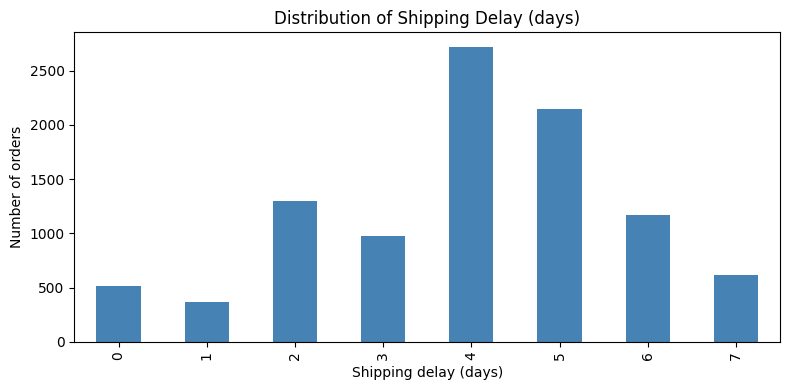

In [22]:
plt.figure(figsize=(8, 4))
df['shipping_delay'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Distribution of Shipping Delay (days)')
plt.xlabel('Shipping delay (days)')
plt.ylabel('Number of orders')
plt.tight_layout()
plt.show()

**Insight:** Shipping delay ranges from 0 to 7 days with an average of ~4 days and no negative or extreme outlier values — this is a clean, well-behaved metric with no data quality concerns. It's also a good candidate derived measure for `fact_sales`, since a business question like "which Ship Mode has the most variable delivery time" is a natural analytical query once the star schema is built.

## 6. Geographic consistency

In [23]:
# One Postal Code shouldn't map to more than one State — check for violations before using
# Postal Code as a lookup key in dim_location.
postal_state_check = df.dropna(subset=['Postal Code']).groupby('Postal Code')['State'].nunique()
bad_postal_codes = postal_state_check[postal_state_check > 1]
print(f"Postal codes mapping to more than one State: {len(bad_postal_codes)}")
bad_postal_codes

Postal codes mapping to more than one State: 0


Series([], Name: State, dtype: int64)

**Insight (fill in after running):** If this comes back empty, `Postal Code` is a safe, stable attribute to store in `dim_location`. If any postal codes map to multiple states, that's a data quality issue to resolve (likely a data entry error, since real US postal codes belong to exactly one state) before using it as a grouping key.

In [24]:
# Similarly, check City -> State consistency (a city name could legitimately repeat across
# different states, e.g. 'Springfield', so this is informational rather than a hard rule)
city_state_check = df.groupby('City')['State'].nunique()
multi_state_cities = city_state_check[city_state_check > 1]
print(f"City names that appear in more than one State: {len(multi_state_cities)}")
multi_state_cities

City names that appear in more than one State: 55


City
Apple Valley      2
Arlington         2
Auburn            3
Aurora            2
Bloomington       2
Bowling Green     2
Bristol           2
Burlington        3
Columbia          4
Columbus          3
Concord           3
Danville          2
Decatur           2
Des Moines        2
Dover             2
Dublin            2
Everett           2
Fairfield         3
Fayetteville      2
Florence          3
Franklin          3
Freeport          2
Henderson         2
Huntsville        2
Jackson           3
Jacksonville      2
Kent              2
Lafayette         2
Lakewood          3
Lancaster         3
Lawrence          2
Lewiston          2
Long Beach        2
Louisville        2
Marion            2
Monroe            2
Mount Pleasant    2
Murray            2
Newark            2
Oak Park          2
Oceanside         2
Pasadena          2
Peoria            2
Quincy            2
Redmond           2
Richmond          3
Rochester         2
Roseville         3
Saint Charles     2
Salem          

**Insight (fill in after running):** Unlike postal codes, a city name legitimately existing in multiple states (e.g., Springfield, IL vs. Springfield, MA) is *not* a data error — it just means `City` alone can't be a unique key in `dim_location`; the natural key needs to be the **City + State** combination (or Postal Code, once validated above).

## 7. Sales column distribution

In [25]:
df['Sales'].describe()

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

In [26]:
# Check for non-positive Sales values, which would be unusual for a sales fact
non_positive_sales = df[df['Sales'] <= 0]
print(f"Rows with Sales <= 0: {len(non_positive_sales)}")
non_positive_sales.head()

Rows with Sales <= 0: 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,shipping_delay


**Insight (fill in after running):** Confirm whether any zero/negative Sales rows exist — if so, decide whether they represent returns/cancellations (keep, but flag) or data errors (investigate/exclude). If none exist, `Sales` is a clean, always-positive measure, which is the expected shape for a fact table's core metric.

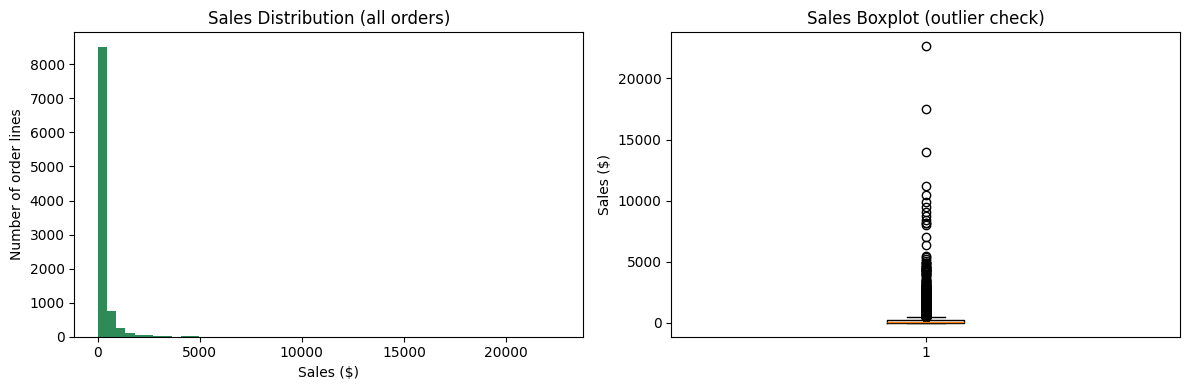

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Sales'], bins=50, color='seagreen')
axes[0].set_title('Sales Distribution (all orders)')
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Number of order lines')

axes[1].boxplot(df['Sales'], vert=True)
axes[1].set_title('Sales Boxplot (outlier check)')
axes[1].set_ylabel('Sales ($)')

plt.tight_layout()
plt.show()

**Insight (fill in after running):** Sales data like this is typically right-skewed — most order lines are low-to-moderate value with a long tail of high-value bulk orders. The boxplot will show these as outliers above the upper whisker; that's expected for retail sales data and usually doesn't need to be removed, but is worth noting in your write-up since it affects whether `mean` or `median` is the more representative summary statistic for reporting.

In [28]:
# Top 10 highest-value single order lines
df.nlargest(10, 'Sales')[['Order ID', 'Customer Name', 'Product Name', 'Category', 'Sales']]

,Order ID,Customer Name,Product Name,Category,Sales
2697,CA-2015-145317,Sean Miller,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.480
6826,CA-2017-118689,Tamara Chand,Canon imageCLASS 2200 Advanced Copier,Technology,17499.950
8153,CA-2018-140151,Raymond Buch,Canon imageCLASS 2200 Advanced Copier,Technology,13999.960
2623,CA-2018-127180,Tom Ashbrook,Canon imageCLASS 2200 Advanced Copier,Technology,11199.968
4190,CA-2018-166709,Hunter Lopez,Canon imageCLASS 2200 Advanced Copier,Technology,10499.970
9039,CA-2017-117121,Adrian Barton,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,9892.740
4098,CA-2015-116904,Sanjit Chand,Ibico EPK-21 Electric Binding System,Office Supplies,9449.950
4277,US-2017-107440,Bill Shonely,"3D Systems Cube Printer, 2nd Generation, Magenta",Technology,9099.930
8488,CA-2017-158841,Sanjit Engle,HP Designjet T520 Inkjet Large Format Printer ...,Technology,8749.950
6425,CA-2017-143714,Christopher Conant,Canon imageCLASS 2200 Advanced Copier,Technology,8399.976


## 8. Category, Segment, Region & Ship Mode value checks

In [29]:
for col in ['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode']:
    print(f"------------ {col} -------------")
    print(df[col].unique())
    print()

------------ Category -------------
['Furniture' 'Office Supplies' 'Technology']

------------ Sub-Category -------------
['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']

------------ Segment -------------
['Consumer' 'Corporate' 'Home Office']

------------ Region -------------
['South' 'West' 'Central' 'East']

------------ Ship Mode -------------
['Second Class' 'Standard Class' 'First Class' 'Same Day']



**Insight (fill in after running):** Scan each list for typos, inconsistent casing, or near-duplicate values (e.g., ' South' vs 'South' with stray whitespace) — these are exactly the kind of silent data quality issues that would otherwise fragment a dimension's attribute values after loading into the warehouse. If everything looks clean, these five columns are ready to use as-is in `dim_customer`/`dim_product`/`dim_location`.

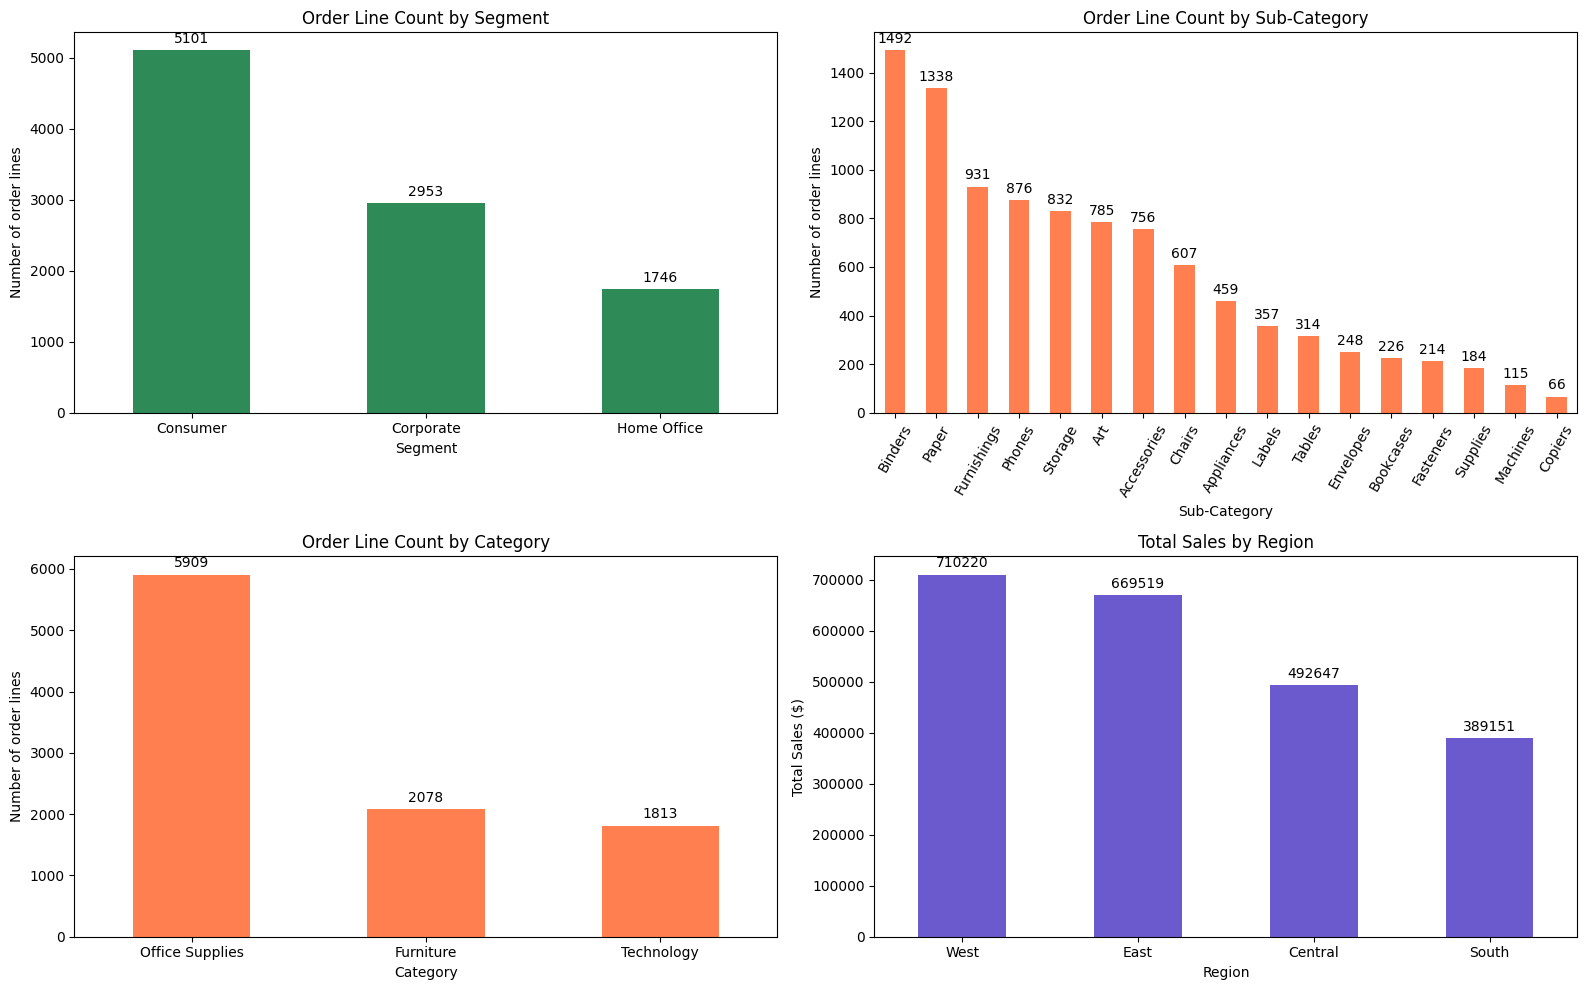

In [30]:
fig, ax = plt.subplots(2, 2, figsize=(16, 10))

# 1. Segment
data = df['Segment'].value_counts()

data.plot(
    kind='bar',
    color='seagreen',
    ax=ax[0, 0]
)

ax[0, 0].set_title('Order Line Count by Segment')
ax[0, 0].set_xlabel('Segment')
ax[0, 0].set_ylabel('Number of order lines')
ax[0, 0].tick_params(axis='x', rotation=0)
ax[0, 0].bar_label(ax[0, 0].containers[0], fmt='%.0f', padding=3)


# 2. Sub-Category
data = df['Sub-Category'].value_counts()

data.plot(
    kind='bar',
    color='coral',
    ax=ax[0, 1]
)

ax[0, 1].set_title('Order Line Count by Sub-Category')
ax[0, 1].set_xlabel('Sub-Category')
ax[0, 1].set_ylabel('Number of order lines')
ax[0, 1].tick_params(axis='x', rotation=60)
ax[0, 1].bar_label(ax[0, 1].containers[0], fmt='%.0f', padding=3)


# 3. Category
data = df['Category'].value_counts()

data.plot(
    kind='bar',
    color='coral',
    ax=ax[1, 0]
)

ax[1, 0].set_title('Order Line Count by Category')
ax[1, 0].set_xlabel('Category')
ax[1, 0].set_ylabel('Number of order lines')
ax[1, 0].tick_params(axis='x', rotation=0)
ax[1, 0].bar_label(ax[1, 0].containers[0], fmt='%.0f', padding=3)


# 4. Sales by Region
data = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

data.plot(
    kind='bar',
    color='slateblue',
    ax=ax[1, 1]
)

ax[1, 1].set_title('Total Sales by Region')
ax[1, 1].set_xlabel('Region')
ax[1, 1].set_ylabel('Total Sales ($)')
ax[1, 1].tick_params(axis='x', rotation=0)
ax[1, 1].bar_label(ax[1, 1].containers[0], fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

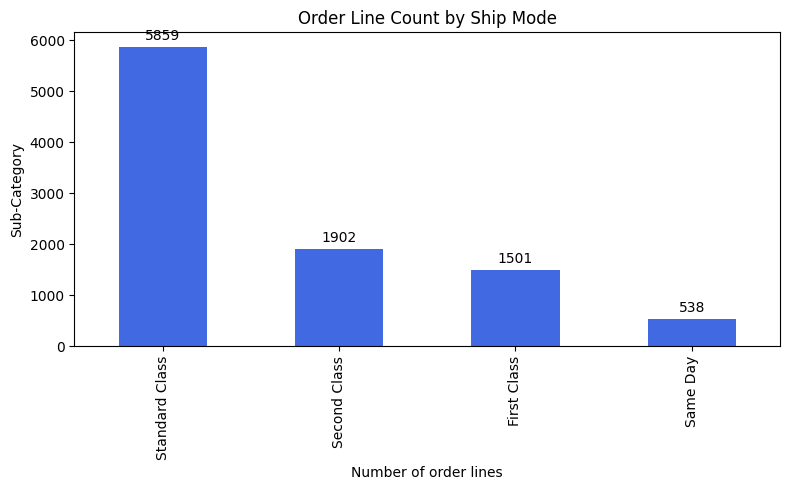

In [31]:
plt.figure(figsize=(8, 5))

data = df['Ship Mode'].value_counts().sort_values(ascending=False)

ax = data.plot(
    kind='bar',
    color='royalblue'
)

plt.title('Order Line Count by Ship Mode')
plt.xlabel('Number of order lines')
plt.ylabel('Sub-Category')

# Add actual values
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

**Insight (fill in after running):** This chart previews the exact kind of business question the finished star schema needs to answer easily — "total sales by region." Note which region leads and by how much; you'll use this same number later to cross-check that your `fact_sales` + `dim_location` join in the warehouse reproduces this figure exactly, which is a good validation step once the ETL is built.

## 9. Summary of findings
- **Grain confirmed:** one row per order line item (9,800 rows across 793 customers, 1,861 products).
- **Data quality:** only `Postal Code` has missing values (11 rows) — everything else is complete, with zero duplicate rows.
- **Dimension readiness:** Customer and Product attribute consistency checked in Section 4 — resolve any inconsistent IDs found before building `dim_customer`/`dim_product`.
- **Date range:** 2015-01-03 to 2018-12-30 (orders), giving a clean 4-year `dim_date`.
- **Derived metric:** `shipping_delay` (0–7 days, avg ~4 days) is clean and usable in `fact_sales`.
- **Geographic keys:** Postal Code vs. State consistency checked in Section 6 — confirm before using Postal Code as a `dim_location` natural key.
- **Next step:** move to `sql/ddl/01_create_schema.sql` to define the star schema based on these findings.